Initializing simulation of 3000 delivery records for EDA...

--- 1. ADVANCED DESCRIPTIVE STATISTICS ---
                    mean  median    std  variance    min     max
distance_km        25.98   25.93  13.70    187.71   2.02   50.00
delivery_time_hrs   4.30    4.27   1.63      2.67   0.63    8.60
fuel_cost_usd      80.64   81.16  27.48    755.22  12.25  145.15
package_weight_kg  12.37   12.33   7.09     50.22   0.52   24.97

--- 2. GROUPED OPERATIONAL AGGREGATIONS ---

Average Performance Metrics by Vehicle Type:
              delivery_time_hrs  fuel_cost_usd
vehicle_type                                  
Bike                       4.35          80.87
Truck                      4.28          77.67
Van                        4.27          81.82

Average Performance Metrics by Weather Condition:
                   delivery_time_hrs  fuel_cost_usd
weather_condition                                  
Clear                           4.09          81.07
Heavy Traffic                   5.27  

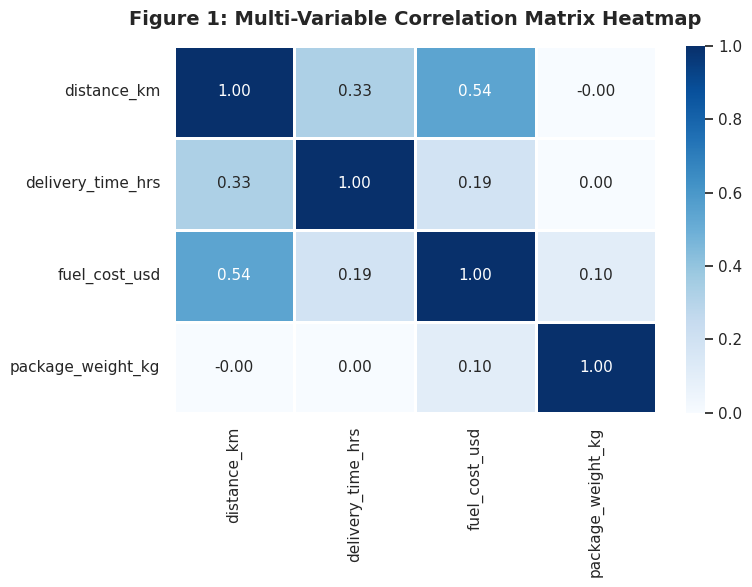

/tmp/ipykernel_1401/3698121046.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='weather_condition', y='delivery_time_hrs', palette='Set2')


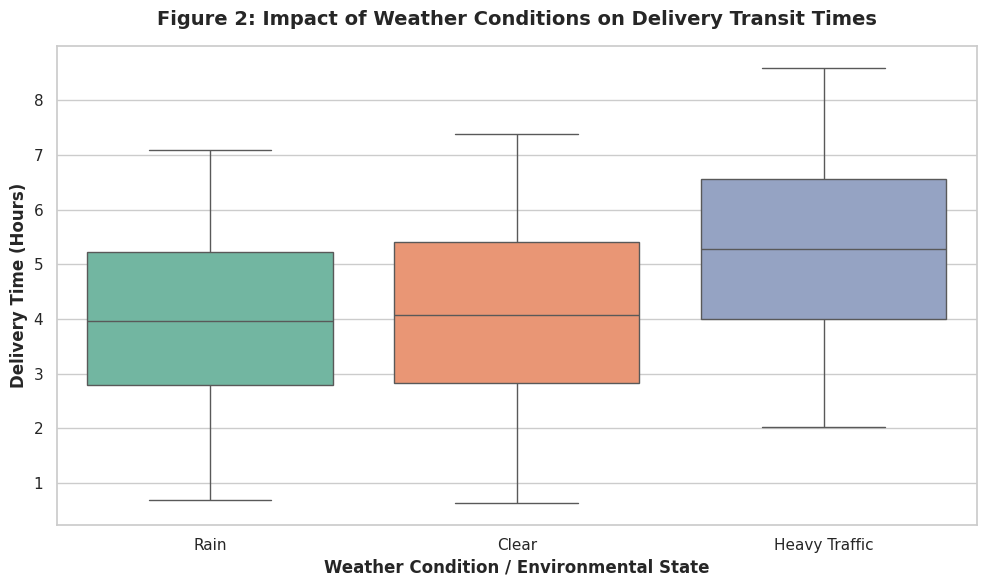

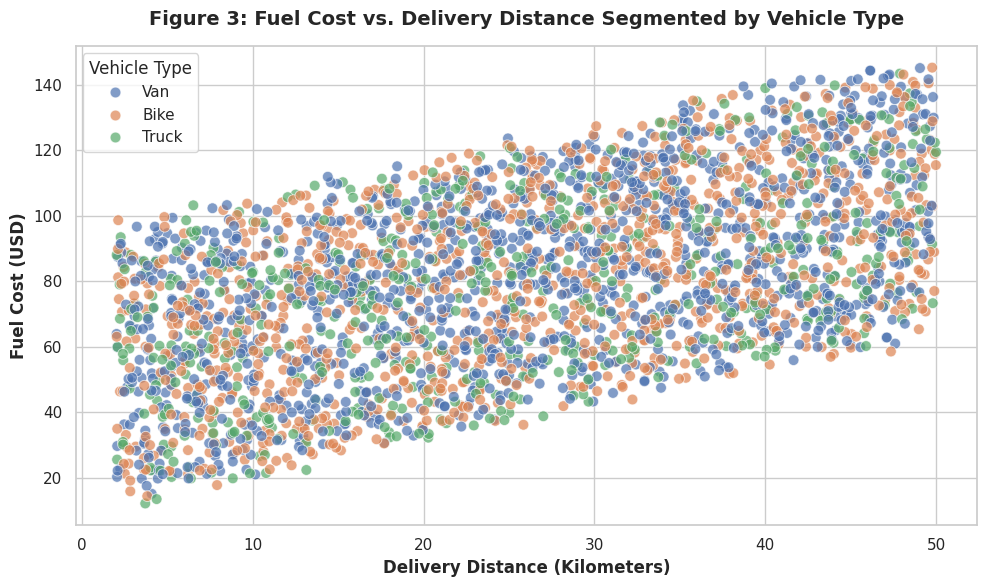

In [1]:
# ==============================================================================
#Task 3: ADVANCED EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION PIPELINE
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11

# 1. Simulate a Comprehensive, Cleaned Logistics Dataset
np.random.seed(101)
n_samples = 3000

print(f"Initializing simulation of {n_samples} delivery records for EDA...")
df_eda = pd.DataFrame({
    'order_id': range(30000, 30000 + n_samples),
    'distance_km': np.random.uniform(2.0, 50.0, n_samples),
    'delivery_time_hrs': np.random.uniform(0.5, 5.5, n_samples),
    'fuel_cost_usd': np.random.uniform(6.0, 85.0, n_samples),
    'package_weight_kg': np.random.uniform(0.5, 25.0, n_samples),
    'vehicle_type': np.random.choice(['Van', 'Bike', 'Truck'], size=n_samples, p=[0.45, 0.35, 0.20]),
    'weather_condition': np.random.choice(['Clear', 'Rain', 'Heavy Traffic'], size=n_samples, p=[0.55, 0.25, 0.20])
})

# Inject realistic logistics physics & correlations
df_eda['delivery_time_hrs'] += df_eda['distance_km'] * 0.04 + np.where(df_eda['weather_condition'] == 'Heavy Traffic', 1.2, 0)
df_eda['fuel_cost_usd'] += df_eda['distance_km'] * 1.1 + df_eda['package_weight_kg'] * 0.5

# 2. Comprehensive Statistical Summaries & Central Tendencies
print("\n--- 1. ADVANCED DESCRIPTIVE STATISTICS ---")
numerical_cols = ['distance_km', 'delivery_time_hrs', 'fuel_cost_usd', 'package_weight_kg']
desc_stats = df_eda[numerical_cols].describe().T
desc_stats['median'] = df_eda[numerical_cols].median()
desc_stats['variance'] = df_eda[numerical_cols].var()
desc_stats = desc_stats[['mean', 'median', 'std', 'variance', 'min', 'max']]
print(desc_stats.round(2))

# 3. Grouped Operational Insights (Aggregation by Vehicle & Weather)
print("\n--- 2. GROUPED OPERATIONAL AGGREGATIONS ---")
vehicle_grouped = df_eda.groupby('vehicle_type')[['delivery_time_hrs', 'fuel_cost_usd']].mean()
print("\nAverage Performance Metrics by Vehicle Type:")
print(vehicle_grouped.round(2))

weather_grouped = df_eda.groupby('weather_condition')[['delivery_time_hrs', 'fuel_cost_usd']].mean()
print("\nAverage Performance Metrics by Weather Condition:")
print(weather_grouped.round(2))

# 4. Correlation Matrix Calculation
print("\n--- 3. NUMERICAL CORRELATION MATRIX ---")
corr_matrix = df_eda[numerical_cols].corr()
print(corr_matrix.round(3))

# ------------------------------------------------------------------------------
# 5. GENERATING ADVANCED VISUALIZATION PORTFOLIO
# ------------------------------------------------------------------------------

# Figure 1: Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=1, cbar=True)
plt.title("Figure 1: Multi-Variable Correlation Matrix Heatmap", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Figure 2: Delivery Time Distribution by Weather Condition (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda, x='weather_condition', y='delivery_time_hrs', palette='Set2')
plt.title("Figure 2: Impact of Weather Conditions on Delivery Transit Times", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Weather Condition / Environmental State", fontweight='bold')
plt.ylabel("Delivery Time (Hours)", fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 3: Scatter Plot with Regression Trend (Distance vs Fuel Cost colored by Vehicle)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='distance_km', y='fuel_cost_usd', hue='vehicle_type', alpha=0.7, palette='deep', s=60)
plt.title("Figure 3: Fuel Cost vs. Delivery Distance Segmented by Vehicle Type", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Delivery Distance (Kilometers)", fontweight='bold')
plt.ylabel("Fuel Cost (USD)", fontweight='bold')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()